<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Project_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 13 - Online Retail Cluster

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [48]:
df = pd.read_excel("Online Retail.xlsx")

In [50]:
df

,InvoiceNo,StockCode,CustomerID,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,536365,71053,17850.0,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,536365,84406B,17850.0,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,536365,84029G,17850.0,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,536365,84029E,17850.0,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,12680.0,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,France
541905,581587,22899,12680.0,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,France
541906,581587,23254,12680.0,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,France
541907,581587,23255,12680.0,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,France


In [51]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
CustomerID,135080
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [52]:
df["CustomerID"].fillna(df["CustomerID"].mean(),inplace=True)

/tmp/ipykernel_2808/1615216874.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CustomerID"].fillna(df["CustomerID"].mean(),inplace=True)


In [53]:
le = LabelEncoder()

In [54]:
df["Country"] = le.fit_transform(df["Country"])
df

,InvoiceNo,StockCode,CustomerID,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,36
1,536365,71053,17850.0,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,36
2,536365,84406B,17850.0,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,36
3,536365,84029G,17850.0,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,36
4,536365,84029E,17850.0,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,36
...,...,...,...,...,...,...,...,...
541904,581587,22613,12680.0,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,13
541905,581587,22899,12680.0,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,13
541906,581587,23254,12680.0,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,13
541907,581587,23255,12680.0,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,13


In [38]:
X = df[["Quantity",'UnitPrice',"Country"]]

In [55]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

In [40]:
X_pca

array([[-3.55144154, -2.06370611],
       [-3.5520146 , -1.22370631],
       [-1.55157857, -1.8623418 ],
       ...,
       [-5.54461373, -0.46282799],
       [-5.54461373, -0.46282799],
       [-6.54515921,  0.33648964]])

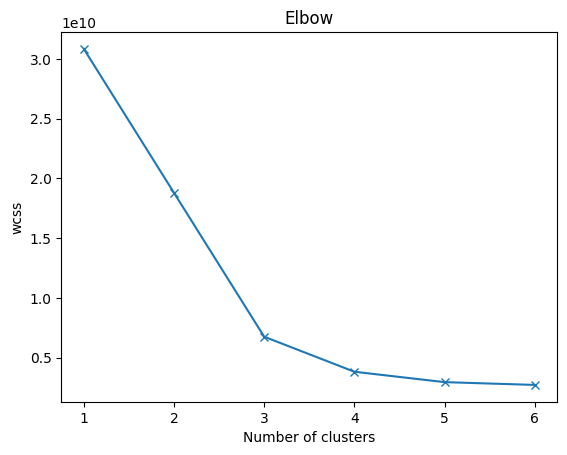

In [56]:
wcss = []
for k in range(1,7):
  km = KMeans(n_clusters=k,random_state=42)
  km.fit(X_pca)
  wcss.append(km.inertia_)
plt.plot(range(1,7),wcss,marker='x')
plt.title("Elbow")
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.show()

In [57]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

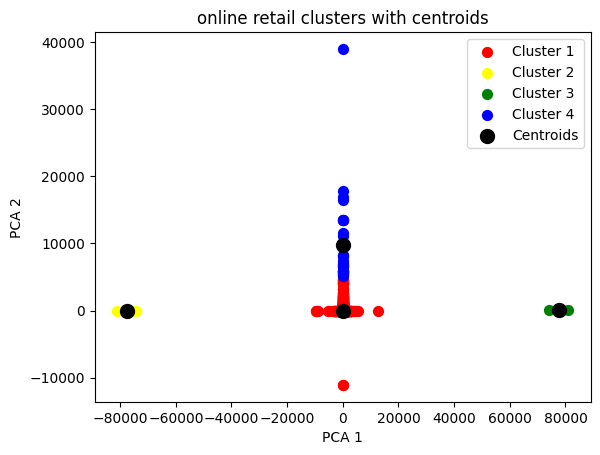

In [58]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red', label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='yellow', label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='green', label='Cluster 3')
plt.scatter(X_pca[y==3,0],X_pca[y==3,1],s=50,c='blue', label='Cluster 4')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.title('online retail clusters with centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')  #0,1,2  clusters #0,1 pca
plt.legend()
plt.show()